# Comprehensive Data Audit: HRP Database

This notebook performs a comprehensive data audit on the HRP database, covering:
1. Setup and Connection
2. Senior Demographics
3. Measurement Volume & Types
4. Physiological Sanity Check (Outliers)
5. Medical History Linkage
6. SOS Alert Categorization
7. The "Golden Sample" Check

In [104]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

## Section 1: Setup & Connection

Connect to the HRP database and load the first 5 rows from each table to verify the schema.

In [2]:
db_path = '../db/hrp_data.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [3]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]
print(f"Tables in database: {tables}\n")

Tables in database: ['seniors', 'measurements', 'sqlite_sequence', 'medical_info', 'diseases', 'medicines', 'senior_diseases', 'senior_medicines', 'alerts', 'ingestion_state']



In [ ]:
table_list = ['seniors', 'measurements', 'alerts', 'senior_diseases', 'senior_medicines']
print(f"Previewing tables: {table_list}")

Previewing tables: ['seniors', 'measurements', 'alerts', 'senior_diseases', 'senior_medicines']


In [31]:
for table in table_list:
    try:
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        total_rows = pd.read_sql_query(f"SELECT COUNT(*) as count FROM {table}", conn)['count'][0]
        print(80 * "=")
        print(f"Table: {table} (Total rows: {total_rows:,})")
        print(80 * "=")
        print(f"Columns: {list(df.columns)}")
        print(f"Data types:\n{df.dtypes}\n")
        print(df.to_string(index=False))
    except Exception as e:
        print(f"Error reading table {table}: {e}")

Table: seniors (Total rows: 13,317)
Columns: ['id', 'gender', 'birthdate', 'age']
Data types:
id            int64
gender       object
birthdate    object
age           int64
dtype: object

  id gender  birthdate  age
2875 Female 1955-02-26   70
3175 Female 1956-09-02   69
3176 Female 1934-08-11   91
3178   Male 1932-12-13   93
3179 Female 1941-11-04   84
Table: measurements (Total rows: 72,654,799)
Columns: ['id', 'senior_id', 'value', 'sbp', 'dbp', 'date', 'type']
Data types:
id             int64
senior_id      int64
value        float64
sbp           object
dbp           object
date          object
type          object
dtype: object

 id  senior_id  value  sbp  dbp                date        type
  1      48129   36.3 None None 2025-11-03 23:16:12 Temperature
  2      48427   36.6 None None 2025-11-03 23:16:12 Temperature
  3      45310   36.3 None None 2025-11-03 23:16:12 Temperature
  4      29421   36.6 None None 2025-11-03 23:16:12 Temperature
  5      45316   36.9 None None 2025

## Section 2: Senior Demographics

Analyze senior population statistics, NULL values, and age outliers.

In [33]:
seniors_df = pd.read_sql_query("SELECT * FROM seniors", conn)

In [53]:
total_seniors = len(seniors_df)
unique_senior_ids = seniors_df['id'].nunique()
print(f"Total seniors: {total_seniors}")
print(f"Unique senior ids: {unique_senior_ids}")

Total seniors: 13317
Unique senior ids: 13317


In [105]:
valid_genders = {'Male', 'Female'}
invalid_gender_rows = seniors_df[~seniors_df['gender'].isin(valid_genders)]
print(f"gender: {len(invalid_gender_rows)} UNKNOWN ({len(invalid_gender_rows)/total_seniors*100:.2f}%)")

null_counts = seniors_df[['birthdate', 'age']].isna().sum()
for col, count in null_counts.items():
    print(f"{col}: {count} NULLs ({count/total_seniors*100:.2f}%)")

gender: 95 UNKNOWN (0.71%)
birthdate: 264 NULLs (1.98%)
age: 249 NULLs (1.87%)


In [76]:
invalid_gender_rows[['id', 'gender', 'age', 'birthdate']].head(5)

,id,gender,age,birthdate
1665,21379,Unknown,69.0,1956-11-26
1666,21380,Unknown,78.0,1947-02-19
1723,21602,Unknown,77.0,1948-11-14
1752,21853,Unknown,69.0,1956-10-19
2086,23496,Unknown,79.0,1946-03-18


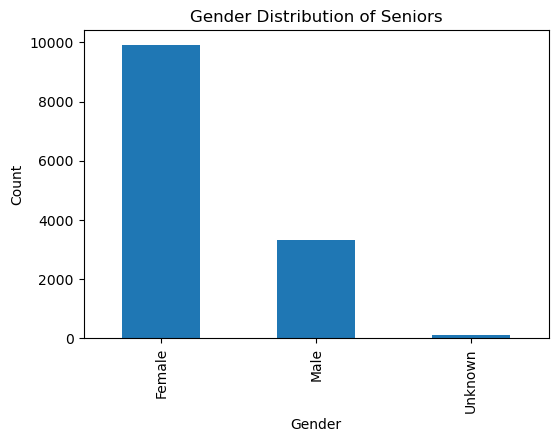

In [ ]:
gender_counts = seniors_df['gender'].value_counts()
plt.figure(figsize=(6, 4))
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution of Seniors')
plt.show()

In [79]:
print(f"Min age: {seniors_df['age'].min()}")
print(f"Max age: {seniors_df['age'].max()}")
print(f"Mean age: {seniors_df['age'].mean():.2f}")
print(f"Median age: {seniors_df['age'].median():.2f}")

Min age: -75.0
Max age: 125.0
Mean age: 76.17
Median age: 77.00


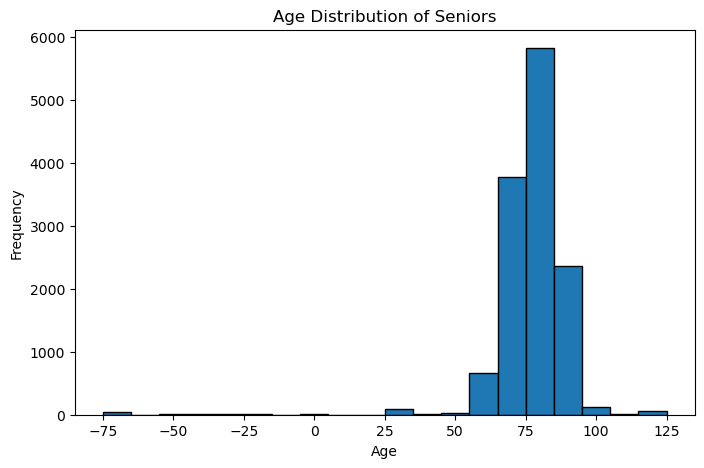

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(seniors_df['age'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Seniors')
plt.show()

In [101]:
# Age outliers
min_age = 50
max_age = 120

age_outliers = seniors_df[(seniors_df['age'] < min_age) | (seniors_df['age'] > max_age)]
print(f"Seniors with age < {min_age}: {len(seniors_df[seniors_df['age'] < min_age])}")
print(f"Seniors with age > {max_age}: {len(seniors_df[seniors_df['age'] > max_age])}")

Seniors with age < 50: 210
Seniors with age > 120: 60


In [103]:
age_outliers[['id', 'gender', 'birthdate', 'age']].head(10)

,id,gender,birthdate,age
802,12453,Female,2022-11-28,3.0
837,12894,Female,2023-01-09,2.0
936,13337,Female,2024-09-06,1.0
1204,18008,Female,2023-04-11,2.0
1775,21885,Female,1988-07-09,37.0
1791,21907,Male,2040-10-30,-15.0
1870,22042,Female,None,125.0
2067,23413,Female,None,125.0
2107,23663,Female,2066-08-14,-41.0
2218,23958,Female,1900-12-31,124.0


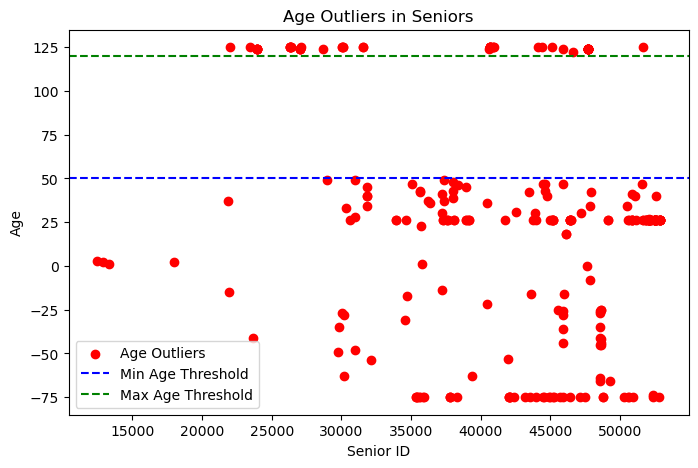

In [122]:
plt.figure(figsize=(8, 5))
plt.scatter(age_outliers['id'], age_outliers['age'], color='red', label='Age Outliers')
plt.axhline(y=min_age, color='blue', linestyle='--', label='Min Age Threshold')
plt.axhline(y=max_age, color='green', linestyle='--', label='Max Age Threshold')
plt.xlabel('Senior ID')
plt.ylabel('Age')
plt.title('Age Outliers in Seniors')
plt.legend()
plt.show()

## Section 3: Measurement Volume & Types

Analyze measurement distribution across types and date range.

In [ ]:
measurements_df = pd.read_sql_query("SELECT * FROM measurements", conn)

MEASUREMENT VOLUME & TYPES AUDIT

--- MEASUREMENTS BY TYPE ---
Heartrate: 16429481 measurements (22.61%)
BloodPressure: 16429476 measurements (22.61%)
Temperature: 16359953 measurements (22.52%)
Saturation: 13121312 measurements (18.06%)
Steps: 10314577 measurements (14.20%)

--- DATE RANGE ---
Min date: 2025-11-01 00:00:02
Max date: 2025-11-30 23:59:59
Total days span: 29 days

--- MEASUREMENTS PER SENIOR ---
Average measurements per senior: 5455.79
Median measurements per senior: 3524.00
Min measurements per senior: 1
Max measurements per senior: 64711
Std dev: 5767.18


In [ ]:
# Measurements by type
print("\n--- MEASUREMENTS BY TYPE ---")
type_counts = measurements_df['type'].value_counts().sort_values(ascending=False)
for type_name, count in type_counts.items():
    print(f"{type_name}: {count} measurements ({count/len(measurements_df)*100:.2f}%)")

In [ ]:
# Date range
print("\n--- DATE RANGE ---")
measurements_df['date'] = pd.to_datetime(measurements_df['date'], format='ISO8601')
min_date = measurements_df['date'].min()
max_date = measurements_df['date'].max()
print(f"Min date: {min_date}")
print(f"Max date: {max_date}")
print(f"Total days span: {(max_date - min_date).days} days")

In [ ]:
# Measurements per senior
print("\n--- MEASUREMENTS PER SENIOR ---")
measurements_per_senior = measurements_df.groupby('senior_id').size()
print(f"Average measurements per senior: {measurements_per_senior.mean():.2f}")
print(f"Median measurements per senior: {measurements_per_senior.median():.2f}")
print(f"Min measurements per senior: {measurements_per_senior.min()}")
print(f"Max measurements per senior: {measurements_per_senior.max()}")
print(f"Std dev: {measurements_per_senior.std():.2f}")

## Subtask 4: Physiological Sanity Check (Outliers)

Analyze vital signs for impossible/unrealistic values.

In [ ]:
print("="*80)
print("PHYSIOLOGICAL SANITY CHECK (OUTLIERS)")
print("="*80)

PHYSIOLOGICAL SANITY CHECK (OUTLIERS)

--- MIN/MAX VALUES BY VITAL TYPE ---

BloodPressure:
  Min: nan
  Max: nan
  Mean: nan

Heartrate:
  Min: 5.00
  Max: 210.00
  Mean: 73.39

Saturation:
  Min: 80.00
  Max: 100.00
  Mean: 97.06

Steps:
  Min: 1.00
  Max: 50147.00
  Mean: 3107.78

Temperature:
  Min: 36.20
  Max: 127.90
  Mean: 36.71

--- IMPOSSIBLE VALUES CHECK ---
Temperature > 45°C or < 30°C: 0
SBP > 250 or < 50 mmHg: 0
SpO2 < 50%: 0

--- SBP/DBP CORRELATION ---
No matching SBP/DBP pairs found for correlation calculation.


In [ ]:
# Vital types and container
vital_types = measurements_df['type'].unique()
vital_stats = {}
print("\n--- MIN/MAX VALUES BY VITAL TYPE ---")

In [ ]:
# Min/Max/Mean per vital type
for vital in sorted(vital_types):
    vital_data = measurements_df[measurements_df['type'] == vital]['value']
    min_val = vital_data.min()
    max_val = vital_data.max()
    mean_val = vital_data.mean()
    vital_stats[vital] = {'min': min_val, 'max': max_val, 'mean': mean_val}
    print(f"\n{vital}:")
    print(f"  Min: {min_val:.2f}")
    print(f"  Max: {max_val:.2f}")
    print(f"  Mean: {mean_val:.2f}")

In [ ]:
# Impossible values checks
print("\n--- IMPOSSIBLE VALUES CHECK ---")

# Temperature > 45 or < 30
temp_data = measurements_df[measurements_df['type'] == 'Temp']['value']
temp_impossible = len(temp_data[(temp_data > 45) | (temp_data < 30)])
print(f"Temperature > 45°C or < 30°C: {temp_impossible}")

# SBP > 250 or < 50
sbp_data = measurements_df[measurements_df['type'] == 'SBP']['value']
sbp_impossible = len(sbp_data[(sbp_data > 250) | (sbp_data < 50)])
print(f"SBP > 250 or < 50 mmHg: {sbp_impossible}")

# SpO2 < 50%
spo2_data = measurements_df[measurements_df['type'] == 'SpO2']['value']
spo2_impossible = len(spo2_data[spo2_data < 50])
print(f"SpO2 < 50%: {spo2_impossible}")

In [ ]:
# SBP/DBP correlation
print("\n--- SBP/DBP CORRELATION ---")
sbp_measurements = measurements_df[measurements_df['type'] == 'SBP'][['senior_id', 'date', 'value']].copy()
sbp_measurements.columns = ['senior_id', 'date', 'sbp_value']
dbp_measurements = measurements_df[measurements_df['type'] == 'DBP'][['senior_id', 'date', 'value']].copy()
dbp_measurements.columns = ['senior_id', 'date', 'dbp_value']

# Merge SBP and DBP by senior_id and date
bp_merged = pd.merge(sbp_measurements, dbp_measurements, on=['senior_id', 'date'])
if len(bp_merged) > 0:
    correlation = bp_merged['sbp_value'].corr(bp_merged['dbp_value'])
    print(f"Correlation between SBP and DBP (n={len(bp_merged)}): {correlation:.4f}")
else:
    print("No matching SBP/DBP pairs found for correlation calculation.")

## Subtask 5: Medical History Linkage

Analyze disease and medication coverage, and profile 3 random seniors.

In [ ]:
# Load disease and medicine data
diseases_df = pd.read_sql_query("SELECT * FROM senior_diseases", conn)
medicines_df = pd.read_sql_query("SELECT * FROM senior_medicines", conn)

MEDICAL HISTORY LINKAGE AUDIT

--- DISEASE LINKAGE ---
Seniors with at least one disease: 8220 (61.73%)
Total disease records: 49444
Avg diseases per senior (with diseases): 6.02

--- MEDICATION LINKAGE ---
Seniors with at least one medication: 8220 (61.73%)
Total medication records: 48304
Avg medications per senior (with meds): 5.88

--- RANDOM SENIOR PROFILES ---

Senior ID: 47143
  Gender: Female
  Age: 85.0
  Birthdate: 1940-12-13
  Diseases: Osteoporoza, Nadciśnienie tętnicze, Arytmia serca, Dyskopatia, Niedoczynnośc tarczycy, Niedosłuch, Miażdzyca, Niewydolność serca, Niedowidzenie, Zaćma, Następstwa udaru mózgu, Rozrusznik serca, Nerwica
  Medications: Letrox, Valsacor, Bisocard, Amlozek

Senior ID: 35017
  Gender: Male
  Age: 87.0
  Birthdate: 1938-01-01
  Diseases: Nadciśnienie tętnicze, Choroba wieńcowa, Niewydolnośc układu krążenia, Niewydolność serca, Niewydolność nerek, Choroba nowotworowa (bez wyszczególnienia), Zatorowość płucna, Stan przedcukrzycowy, Nowotwór jelita gru

In [ ]:
# Load disease and medicine lookup tables
try:
    diseases_lookup = pd.read_sql_query("SELECT * FROM diseases", conn)
except Exception:
    diseases_lookup = None

try:
    medicines_lookup = pd.read_sql_query("SELECT * FROM medicines", conn)
except Exception:
    medicines_lookup = None

In [ ]:
print("="*80)
print("MEDICAL HISTORY LINKAGE AUDIT")
print("="*80)

In [ ]:
# Disease linkage
print(f"\n--- DISEASE LINKAGE ---")
seniors_with_disease = diseases_df['senior_id'].nunique()
disease_coverage = seniors_with_disease / total_seniors * 100
print(f"Seniors with at least one disease: {seniors_with_disease} ({disease_coverage:.2f}%)")
print(f"Total disease records: {len(diseases_df)}")
if seniors_with_disease > 0:
    print(f"Avg diseases per senior (with diseases): {len(diseases_df) / seniors_with_disease:.2f}")

In [ ]:
# Medication linkage
print(f"\n--- MEDICATION LINKAGE ---")
seniors_with_medicine = medicines_df['senior_id'].nunique()
medicine_coverage = seniors_with_medicine / total_seniors * 100
print(f"Seniors with at least one medication: {seniors_with_medicine} ({medicine_coverage:.2f}%)")
print(f"Total medication records: {len(medicines_df)}")
if seniors_with_medicine > 0:
    print(f"Avg medications per senior (with meds): {len(medicines_df) / seniors_with_medicine:.2f}")

In [ ]:
# Random senior profiles
print(f"\n--- RANDOM SENIOR PROFILES ---")
np.random.seed(42)
random_seniors = np.random.choice(seniors_df['id'].values, 3, replace=False)

for senior_id in random_seniors:
    print(f"\n{'='*60}")
    print(f"Senior ID: {senior_id}")
    senior_info = seniors_df[seniors_df['id'] == senior_id].iloc[0]
    print(f"  Gender: {senior_info['gender']}")
    print(f"  Age: {senior_info['age']}")
    print(f"  Birthdate: {senior_info['birthdate']}")
    
    # Diseases
    if diseases_lookup is not None:
        senior_disease_ids = diseases_df[diseases_df['senior_id'] == senior_id]['disease_id'].tolist()
        diseases_list = diseases_lookup[diseases_lookup['id'].isin(senior_disease_ids)]['disease_name'].tolist()
        print(f"  Diseases: {', '.join(diseases_list) if diseases_list else 'None'}")
    else:
        print(f"  Diseases: (lookup table not found)")
    
    # Medications
    if medicines_lookup is not None:
        senior_medicine_ids = medicines_df[medicines_df['senior_id'] == senior_id]['medicine_id'].tolist()
        medicines_list = medicines_lookup[medicines_lookup['id'].isin(senior_medicine_ids)]['medicine_name'].tolist()
        print(f"  Medications: {', '.join(medicines_list) if medicines_list else 'None'}")
    else:
        print(f"  Medications: (lookup table not found)")

## Subtask 6: SOS Alert Categorization

Categorize alerts into TECHNICAL, REAL, and UNVERIFIED based on alert notes.

In [ ]:
# Load alerts data
alerts_df = pd.read_sql_query("SELECT * FROM alerts", conn)
alerts_df['alert_date'] = pd.to_datetime(alerts_df['alert_date'], format='ISO8601')

SOS ALERT CATEGORIZATION

--- ALERT CATEGORIES ---
REAL: 73 (1.35%)
TECHNICAL: 5262 (97.08%)
UNVERIFIED: 85 (1.57%)

Total alerts: 5420

--- CATEGORY EXAMPLES ---

TECHNICAL examples:
  3205 (2025-11-30 17:07:51): Alarm przypadkowy
  3221 (2025-11-25 19:38:36): Alarm przypadkowy
  3275 (2025-11-14 15:01:34): Alarm przypadkowy

REAL examples:
  9621 (2025-11-23 21:09:20): Alarm. Nawiązano kontakt z Seniorem. W wyniku przeprowadzonej oceny stanu pacjenta wykryto sytuację zagrożenia życia i zdrowia. Zdecydowano się na interwencję ZRM.
  9621 (2025-11-23 21:08:22): Alarm. Nawiązano kontakt z Seniorem. W wyniku przeprowadzonej oceny stanu pacjenta wykryto sytuację zagrożenia życia i zdrowia. Zdecydowano się na interwencję ZRM.
  9621 (2025-11-21 18:29:00): Alarm. Nawiązano kontakt z Seniorem. W wyniku przeprowadzonej oceny stanu pacjenta wykryto sytuację zagrożenia życia i zdrowia. Zdecydowano się na interwencję ZRM.

UNVERIFIED examples:
  8862 (2025-11-28 10:24:20): (empty)
  16399 (2025-

In [ ]:
print("="*80)
print("SOS ALERT CATEGORIZATION")
print("="*80)

In [ ]:
# Categorize alerts function
def categorize_alert(note):
    if pd.isna(note) or note == '' or note is None:
        return 'UNVERIFIED'
    note_lower = str(note).lower()
    technical_keywords = [
        'testowy',
        'przypadkowy',
        'techniczny',
        'test',
        'próba',
        'brak wskazań',
        'bez wskazań'
    ]
    return 'TECHNICAL' if any(keyword in note_lower for keyword in technical_keywords) else 'REAL'

In [ ]:
# Apply categorization
alerts_df['category'] = alerts_df['sos_note'].apply(categorize_alert)
print("\n--- ALERT CATEGORIES ---")
category_counts = alerts_df['category'].value_counts()
for category, count in sorted(category_counts.items()):
    pct = count / len(alerts_df) * 100
    print(f"{category}: {count} ({pct:.2f}%)")
print(f"\nTotal alerts: {len(alerts_df)}")

In [ ]:
# Show examples per category
print("\n--- CATEGORY EXAMPLES ---")
for category in ['TECHNICAL', 'REAL', 'UNVERIFIED']:
    print(f"\n{category} examples:")
    examples = alerts_df[alerts_df['category'] == category][['senior_id', 'alert_date', 'sos_note']].head(3)
    for _, row in examples.iterrows():
        note = row['sos_note'] if pd.notna(row['sos_note']) else "(empty)"
        print(f"  {row['senior_id']} ({row['alert_date']}): {note}")

## Subtask 7: The "Golden Sample" Check

For alerts marked as REAL, check if there are at least 50 measurement rows in the 72 hours before the alert.

In [ ]:
print("="*80)
print("THE GOLDEN SAMPLE CHECK (PREDICTABLE ALERTS)")
print("="*80)

# Filter for REAL alerts only
real_alerts = alerts_df[alerts_df['category'] == 'REAL'].copy()
print(f"\nTotal REAL alerts: {len(real_alerts)}")

THE GOLDEN SAMPLE CHECK (PREDICTABLE ALERTS)

Total REAL alerts: 73

--- PREDICTABILITY ANALYSIS ---
Alerts with >= 50 measurements in 72 hours before: 56 (76.71%)
Alerts with < 50 measurements: 17 (23.29%)

--- MEASUREMENT COUNT DISTRIBUTION (72h before alert) ---
count      73.000000
mean      669.972603
std       615.982954
min         0.000000
25%        85.000000
50%       678.000000
75%      1140.000000
max      1826.000000
Name: measurements_72h_before, dtype: float64

--- PREDICTABLE ALERTS (first 5) ---
Senior 9621: 85 measurements before 2025-11-23 21:09:20
Senior 9621: 85 measurements before 2025-11-23 21:08:22
Senior 13336: 949 measurements before 2025-11-19 08:44:59
Senior 13336: 949 measurements before 2025-11-19 08:43:46
Senior 16008: 1676 measurements before 2025-11-05 18:56:04

--- UNPREDICTABLE ALERTS (first 5) ---
Senior 9621: 16 measurements before 2025-11-21 18:29:00
Senior 11069: 24 measurements before 2025-11-05 15:57:24
Senior 16437: 0 measurements before 2025-1

In [ ]:
# Build predictability details
predictable_count = 0
alert_details = []

for _, alert in real_alerts.iterrows():
    senior_id = alert['senior_id']
    alert_time = alert['alert_date']
    time_window_start = alert_time - timedelta(hours=72)
    measurements_before = measurements_df[
        (measurements_df['senior_id'] == senior_id) &
        (pd.to_datetime(measurements_df['date']) >= time_window_start) &
        (pd.to_datetime(measurements_df['date']) <= alert_time)
    ]
    measurement_count = len(measurements_before)
    has_enough_data = measurement_count >= 50
    alert_details.append({
        'senior_id': senior_id,
        'alert_time': alert_time,
        'measurements_72h_before': measurement_count,
        'is_predictable': has_enough_data
    })
    if has_enough_data:
        predictable_count += 1

In [ ]:
# Predictability analysis summary
predictable_df = pd.DataFrame(alert_details)
print(f"\n--- PREDICTABILITY ANALYSIS ---")
print(f"Alerts with >= 50 measurements in 72 hours before: {predictable_count} ({(predictable_count/len(real_alerts)*100 if len(real_alerts)>0 else 0):.2f}%)")
print(f"Alerts with < 50 measurements: {len(real_alerts) - predictable_count} ({(((len(real_alerts) - predictable_count)/len(real_alerts))*100 if len(real_alerts)>0 else 0):.2f}%)")

print(f"\n--- MEASUREMENT COUNT DISTRIBUTION (72h before alert) ---")
print(predictable_df['measurements_72h_before'].describe())

In [ ]:
# Example alerts
print(f"\n--- PREDICTABLE ALERTS (first 5) ---")
predictable_alerts = predictable_df[predictable_df['is_predictable']].head(5)
for _, row in predictable_alerts.iterrows():
    print(f"Senior {row['senior_id']}: {row['measurements_72h_before']} measurements before {row['alert_time']}")

print(f"\n--- UNPREDICTABLE ALERTS (first 5) ---")
unpredictable_alerts = predictable_df[~predictable_df['is_predictable']].head(5)
for _, row in unpredictable_alerts.iterrows():
    print(f"Senior {row['senior_id']}: {row['measurements_72h_before']} measurements before {row['alert_time']}")

In [ ]:
# Summary
print(f"\n{'='*80}")
print(f"SUMMARY: {predictable_count} out of {len(real_alerts)} REAL alerts are 'Predictable'")
print(f"{'='*80}")

In [ ]:
# Close the database connection
conn.close()
print("\nDatabase connection closed.")